# Example: Out-of-Sample Single-Asset GBM Simulation
How well does a model fitted to past prices describe prices observed afterward? Out-of-sample testing evaluates a model using data that were __not used to estimate its parameters__. Here, we use the mean growth rate and volatility estimated from 2014 to 2024 data, and compare the resulting geometric Brownian motion (GBM) predictions with observed prices in 2025.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Simulate out-of-sample prices:** Construct a single-asset GBM model using mean growth and volatility estimated from the training period, including the conversion from mean growth to drift. Use the exact GBM transition to generate possible price paths through the testing period and compare them with the observed price series.
> * **Calculate pointwise prediction bands:** Compute the expected price and lognormal quantile bands that describe the model's price distribution at each forecast date, with fitted parameters held fixed. Interpret the band probabilities and explain why a 95% prediction band does not imply a 95% probability that the entire price path stays inside it.
> * **Evaluate observed coverage:** Measure the fraction of forecast dates inside each prediction band and the largest standardized log-price deviation, then compare these diagnostics across assets. Use the histogram and coverage tables to identify assets for closer examination, and explain how band width and dependence between forecast dates limit what coverage alone can tell us.

In this example, we first simulate one asset and compare its observed prices with the model's prediction bands. We then repeat the coverage calculation for every asset shared by the training parameter table and the testing dataset. Each forecast starts from the asset's first observed testing price, with the fitted parameters held fixed.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the required packages, and includes local helper code.

Let's set up our code environment:

In [1]:
# Load the course environment and the local prediction-band/coverage helpers -
include(joinpath(@__DIR__, "Include.jl")); # resolve the setup file from this notebook's directory

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 2, 2025 until December 31, 2025, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet).

In [2]:
# Load held-out 2025 prices; fitted parameters will come from the earlier training period -
original_dataset = MyTestingMarketDataSet() |> x -> x["dataset"]; # load the testing data by ticker

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days to ensure we have consistent, complete time series for reliable analysis.

First, let's use a firm known to have a complete record, `AAPL`, to compute the maximum number of trading days. We save that value in `maximum_number_trading_days::Int64`:

In [3]:
# Use AAPL's complete testing record to set the required price-history length -
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # includes the initial price observation

250

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}(); # ticker → retained testing-price table

    # Retain full testing histories before matching firms to fitted parameters -
    for (ticker, data) ∈ original_dataset 
        if (nrow(data) == maximum_number_trading_days) # retain tickers with complete histories
            dataset[ticker] = data;
        end
    end
    dataset; # return the filtered dictionary; no parameters are fitted to these prices
end;

Now, let's load the GBM parameters estimated from the 2014 to 2024 training data in [the L4b parameter-estimation example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). We copied that file into this lecture's `data` folder, so rerunning the L4b example does not change the values used here. We store the table in the `parameters_df::DataFrame` variable. The legacy `drift` column contains the mean growth rate estimate $\hat{\mu}_g$, and the `volatility` column contains $\hat{\sigma}$. We will convert mean growth to GBM drift when we build the model.

In [5]:
parameters_df = let

    # Load the saved 2014–2024 estimates -
    # The legacy drift column is mean log growth ĝ; the model needs ĝ + σ̂²/2.
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # retain ticker names so subsequent lookups do not depend on CSV row order
end;

The training parameter table and testing dataset contain different sets of tickers. To simulate an asset, we need both its fitted parameters and a complete testing record. Let's collect the tickers shared by the two datasets, sort them alphabetically, and save them in `list_of_tickers::Array{String,1}`. We will continue to look up each asset's parameters by ticker name because the row positions in the parameter table can differ from positions in this list:

In [6]:
list_of_tickers = let
    # Keep assets with both a complete testing record and fitted parameters.
    testing_tickers = collect(keys(dataset)); # names with complete held-out histories
    training_tickers = String.(parameters_df.ticker); # normalize names to the dictionary key type
    sort(intersect(testing_tickers, training_tickers)); # deterministic list with both required inputs
end;
println("Assets available for simulation: $(length(list_of_tickers))")

Assets available for simulation: 417


### Constants and Parameters
Let's define the constants and parameters used in the simulations. The adjacent comments document each value and its units.

In [7]:
# Match one simulated time point to each observed testing price -
Δt = (1.0/252.0); # time step (1 trading day, in years)
TSIM = maximum_number_trading_days; # number of price rows, including the initial condition; there are TSIM-1 steps
Random.seed!(5660); # reproduce paths when the simulation cells are run in the same order

___

## Task 1: Simulate Future Prices for One Asset
In this task, we use a GBM model fitted to the training data to simulate share prices over the 2025 testing period.

Let's select a ticker from `list_of_tickers` and save it in `ticker_to_simulate::String`. We start with `SPY`, an exchange-traded fund that tracks the S&P 500 index; you can select another ticker from the shared list:

In [8]:
# Choose the asset; rerun the dependent cells after changing this ticker -
ticker_to_simulate = "SPY"; # select a ticker symbol from the list_of_tickers array
random_firm_data = dataset[ticker_to_simulate]; # extract the 2025 data for this ticker

Next, let's extract the initial share price, the volume-weighted average price (VWAP) on the first trading day of 2025, and save this value in the `Sₒ::Float64` variable. We use the VWAP throughout so that the simulation starts from the same price series we compare against:

In [9]:
Sₒ = let
    # Initialize every path from the same observed purchase-date price -
    data = dataset[ticker_to_simulate]; # extract the data for this ticker
    Sₒ = data[1,:volume_weighted_average_price]; # initial share price (VWAP on the first day of the testing set)
    Sₒ; # USD/share; the first observed price is an initial condition, not a forecast
end;

### Generate sample price trajectories for a GBM model
Create an instance of [the `MyGeometricBrownianMotionEquityModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyGeometricBrownianMotionEquityModel) using [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyGeometricBrownianMotionEquityModel},%20NamedTuple}).

The parameter table stores the mean growth rate estimate $\hat{\mu}_g$ in its legacy `drift` column. The model requires the GBM drift, so we use the relationship developed in L4b:
$$
\hat{\mu} = \hat{\mu}_g + \frac{\hat{\sigma}^{2}}{2}.
$$
We find the asset's row by ticker name. In the code, `ĝ` stores $\hat{\mu}_g$ and `μ̂` stores the drift $\hat{\mu}$. We pass the drift and volatility to the constructor and save the result in `model::MyGeometricBrownianMotionEquityModel`:

In [10]:
model = let

    # Match the ticker by name; training-table and testing-list positions can differ -
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker);
    @assert !isnothing(j) "no training parameters for $(ticker_to_simulate)"
    ĝ = parameters_df[j, :drift]; # fitted mean growth rate μ̂_g (1/year)
    σ̂ = parameters_df[j, :volatility]; # fitted volatility (1/sqrt(year))

    # The sampler subtracts σ̂²/2 in log space, so this conversion restores mean log growth ĝ.
    μ̂ = ĝ + 0.5*σ̂^2; # GBM drift (1/year)
    println("Firm-$(ticker_to_simulate): (ĝ, σ̂, μ̂) = ($(round(ĝ,digits=4)), $(round(σ̂,digits=4)), $(round(μ̂,digits=4)))")

    # Build the price-SDE model with fitted parameters held fixed -
    model = build(MyGeometricBrownianMotionEquityModel, (
            μ = μ̂, σ = σ̂ )); # package API uses μ for the GBM price-SDE drift

    model; # Return
end;

Firm-SPY: (ĝ, σ̂, μ̂) = (0.1031, 0.1351, 0.1123)


Next, let's compute the simulated future prices using [the `sample(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}), which advances the price with the exact one-step transition of the lecture. The time grid runs from the first to the last trading day of the testing set, one row per day, so the sample array `X::Array{Float64,2}` has the same number of rows as we have observations (the first column is time, the remaining columns are the sample paths):

In [11]:
X, T₁, T₂ = let

    T₁ = 0.0; # elapsed time at the first 2025 observation
    T₂ = (TSIM - 1)*Δt; # TSIM rows: one initial condition plus TSIM - 1 steps
    number_of_paths = 100; # number of sample paths to generate

    # Apply the exact GBM transition at each step -
    # X has TSIM rows; column 1 is time and each remaining column is one path.
    X = VLQuantitativeFinancePackage.sample(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt), 
            number_of_paths = number_of_paths);

    X, T₁, T₂; # return paths and horizon together so analytical results use the same grid
end;

___

## Task 2: Prediction Bands and Coverage for One Asset
In this task, we calculate the model's expected price and prediction bands, then measure how often the observed price falls inside those bands. The sampled paths show possible price trajectories; the analytical expressions describe the model's price distribution at each future date.

We treat the training-period parameter estimates as fixed and use the observed VWAP on the first testing day as $S_0$. Let $\tau$ be the elapsed time in years from that initial observation. The expected share price is given by:
$$
\mathbb{E}[S(\tau)] = S_0\exp(\hat{\mu}\tau).
$$
Let's compute this expectation on the same time grid as the sample paths using [the `expectation(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.expectation-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}). We save its time and expected-price columns in `expectation_array`:

In [12]:
# Evaluate S₀ exp(μ̂t) analytically; this is not the finite-sample average of X -
# The returned columns are time (years) and expected price (USD/share).
expectation_array = expectation(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));

### Construct the prediction bands
At a fixed elapsed time $\tau>0$, the fitted GBM model gives the log price ratio as:
$$
\ln\!\left(\frac{S(\tau)}{S_0}\right)
= \hat{\mu}_g\tau + \hat{\sigma}\sqrt{\tau}\,Z,
\qquad Z\sim\mathcal{N}(0,1).
$$
A central normal interval $-z\leq Z\leq z$ becomes a price interval when we exponentiate. Its lower and upper limits are therefore given by:
$$
\begin{aligned}
L_z(\tau) &= S_0\exp\!\left(\hat{\mu}_g\tau-z\hat{\sigma}\sqrt{\tau}\right),\\
U_z(\tau) &= S_0\exp\!\left(\hat{\mu}_g\tau+z\hat{\sigma}\sqrt{\tau}\right).
\end{aligned}
$$
Using $z=1$, $1.96$, and $2.576$ gives approximately 68%, 95%, and 99% __pointwise prediction intervals__. Each probability applies to one future date with the fitted parameters held fixed. It does not describe the probability that an entire path remains inside the band, and these bands do not include uncertainty in the estimated parameters.

The median price is $S_0\exp(\hat{\mu}_g\tau)$. The expected price lies above it for $\tau>0$ because $\hat{\mu}=\hat{\mu}_g+\hat{\sigma}^2/2$.

[The `gbm_prediction_band(...)` function](docs/oos-functions.md#gbm_prediction_band) computes the lower and upper limits from the median-price vector, volatility, elapsed times, and the selected value of $z$.

`Unhide` the next cell to see how we plot the analytical expectation, median, and shaded prediction bands alongside the sampled trajectories and observed VWAP. The observed price is shown in red, the sampled paths are shown in gray, and the expectation is shown as a dashed blue line:

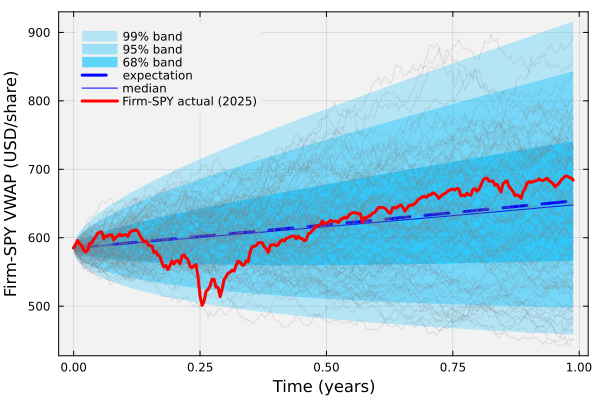

In [13]:
let
    
    # Align model quantities and observed prices on the same grid -
    time_axis = expectation_array[:,1]; # absolute time (years)
    τ = time_axis .- time_axis[1]; # elapsed time from the initial observation (years)
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker); # row for the selected asset
    ĝ = parameters_df[j, :drift]; # fitted mean growth rate μ̂_g (1/year)
    σ̂ = parameters_df[j, :volatility]; # fitted volatility (1/sqrt(year))
    μ̂ = ĝ + 0.5*σ̂^2; # GBM drift (1/year)
    median_value = Sₒ*exp.((μ̂ - 0.5*σ̂^2)*τ); # lognormal median price (USD/share)

    # Compute lognormal quantiles at each date with parameter estimates held fixed -
    # These bands describe separate dates, not simultaneous coverage of an entire path.
    (L68,U68) = gbm_prediction_band(median_value, σ̂, τ; z = 1.0);
    (L95,U95) = gbm_prediction_band(median_value, σ̂, τ; z = 1.96);
    (L99,U99) = gbm_prediction_band(median_value, σ̂, τ; z = 2.576);
    actual = random_firm_data[1:TSIM, :volume_weighted_average_price];
    @assert length(actual) == length(time_axis) "band and observation lengths differ"

    # Draw the widest band first so the narrower bands remain visible on top -
    # fillrange shades between lower and upper prices; it is not a symmetric price error bar.
    plot(time_axis, U99, fillrange=L99, c=:deepskyblue1, alpha=0.25, label="99% band", lw=0)
    plot!(time_axis, U95, fillrange=L95, c=:deepskyblue1, alpha=0.35, label="95% band", lw=0)
    plot!(time_axis, U68, fillrange=L68, c=:deepskyblue1, alpha=0.6, label="68% band", lw=0)
    plot!(time_axis, expectation_array[:,2], c=:blue, lw=3, ls=:dash, label="expectation")
    plot!(time_axis, median_value, c=:blue, lw=1, label="median")
    for i ∈ 2:size(X,2) # column 1 is time, columns 2:end are the sample paths
        plot!(X[:,1], X[:,i], c=:gray50, lw=1, alpha=0.2, label="")
    end
    # Overlay the observed path after the simulations so it remains visible.
    plot!(time_axis, actual, lw=3, c=:red, label="Firm-$(ticker_to_simulate) actual (2025)")
    xlabel!("Time (years)", fontsize=18)
    ylabel!("Firm-$(ticker_to_simulate) VWAP (USD/share)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end

### Check: How often did the observed price stay inside the bands?
Let's count the fraction of trading days on which the observed VWAP falls inside the 95% and 99% bands. We score only the forecast days: the first observation sets $S_0$, so it lies inside every band by construction.

If the model and its parameters were correct, each forecast day's coverage probability would be approximately 95% or 99%. The fractions observed over one year can differ from those values because prices along a single path are dependent; a path that leaves a band can remain outside it for several days. We use the observed coverage fractions as descriptive diagnostics of the fitted model.

[The `band_coverage(...)` function](docs/oos-functions.md#band_coverage) compares each forecast price with its lower and upper limits and returns the fraction inside the band. Let's use it to calculate and report both fractions for the selected asset:

In [14]:
let
    # Score the observed path against the fitted bands, without using simulated draws -
    j = findfirst(==(ticker_to_simulate), parameters_df.ticker); # row for the selected asset
    ĝ = parameters_df[j, :drift]; # fitted mean growth rate μ̂_g (1/year)
    σ̂ = parameters_df[j, :volatility]; # fitted volatility (1/sqrt(year))
    τ = collect(0:(TSIM-1)) .* Δt; # elapsed time from the initial observation (years)
    actual = random_firm_data[1:TSIM, :volume_weighted_average_price] |> collect; # observed VWAP (USD/share)
    # The helper includes equality at the band limits and excludes the initial row at τ=0.
    c95 = band_coverage(Sₒ, ĝ, σ̂, τ, actual; z = 1.96); # fraction inside the 95% band (dimensionless)
    c99 = band_coverage(Sₒ, ĝ, σ̂, τ, actual; z = 2.576); # fraction inside the 99% band (dimensionless)
    println("Firm-$(ticker_to_simulate): fraction of 2025 trading days inside the 95% band = $(round(c95, digits=3)); inside the 99% band = $(round(c99, digits=3))")
end

Firm-SPY: fraction of 2025 trading days inside the 95% band = 0.976; inside the 99% band = 0.996


___

## Task 3: Coverage Across the Shared Dataset
In this task, we repeat the coverage calculation for every asset in `list_of_tickers`, the tickers shared by the training parameter table and the testing dataset. Each asset uses its own initial VWAP and fitted parameters, so we can examine how the results vary across the dataset.

For each asset, we calculate the fraction of forecast days inside the 95% and 99% bands. Coverage tells us how often the observed price lies inside a band. We also want to measure how far the observed log price moves from the model's median path.

Let $S_k$ be the observed VWAP at forecast date $k$, and let $\tau_k=k\Delta t$ be the elapsed time from the initial observation. We compare the observed log price ratio with its fitted mean and divide by its modeled standard deviation:
$$
z_k = \frac{\ln(S_k/S_0)-\hat{\mu}_g\tau_k}
{\hat{\sigma}\sqrt{\tau_k}},
\qquad k=1,\ldots,N,
$$
where $N=\texttt{TSIM}-1$ is the number of forecast dates. The initial observation is $k=0$ and is excluded. Positive values of $z_k$ place the observed price above the model's median; negative values place it below. The largest absolute deviation over the testing period is given by:
$$
z_{\max}=\max_{k=1,\ldots,N}|z_k|.
$$
A value above $1.96$ identifies at least one forecast day outside the 95% band. This maximum is a descriptive diagnostic. Assigning a probability to an observed maximum would require accounting for all forecast dates and their dependence.

[The `max_abs_z(...)` function](docs/oos-functions.md#max_abs_z) computes $z_{\max}$ for each asset.

Let's store the coverage fractions, maximum deviation, fitted parameters, and final-to-initial price ratio in `coverage_df::DataFrame`. The `max_abs_z` column stores $z_{\max}$. We sort the rows by decreasing 95% coverage and break ties by increasing $z_{\max}$, because many assets have coverage of one:

In [15]:
coverage_df = let
    df = DataFrame(ticker = String[], coverage_95 = Float64[], coverage_99 = Float64[], max_abs_z = Float64[], ĝ = Float64[], σ̂ = Float64[], price_ratio = Float64[]);
    τ = collect(0:(TSIM-1)) .* Δt; # array position k+1 corresponds to elapsed time kΔt
    # Visit the shared tickers; each has fitted parameters and a complete testing history -
    for ticker ∈ list_of_tickers
        j = findfirst(==(ticker), parameters_df.ticker); # look up parameters by name, not by row position
        ĝ = parameters_df[j, :drift]; # fitted mean growth rate μ̂_g (1/year)
        σ̂ = parameters_df[j, :volatility]; # fitted volatility (1/sqrt(year))
        prices = dataset[ticker][1:TSIM, :volume_weighted_average_price] |> collect;
        S₀ = prices[1]; # each asset starts from its own first observed VWAP
        c95 = band_coverage(S₀, ĝ, σ̂, τ, prices; z = 1.96);
        c99 = band_coverage(S₀, ĝ, σ̂, τ, prices; z = 2.576);
        # max_abs_z excludes τ=0 to avoid division by zero; it is a descriptive maximum.
        # The final price ratio uses only endpoints, while coverage uses all forecast dates.
        push!(df, (ticker, c95, c99, max_abs_z(S₀, ĝ, σ̂, τ, prices), ĝ, σ̂, prices[end]/S₀));
    end
    # Many assets tie at coverage one; break ties by the smallest maximum deviation -
    sort!(df, [order(:coverage_95, rev = true), order(:max_abs_z)]); # later tables use this order
    df
end;
# Boolean means give fractions of firms satisfying each coverage threshold -
println("Firms scored: $(nrow(coverage_df)); median 95% coverage = $(round(median(coverage_df.coverage_95), digits=3)); fraction of firms with 95% coverage above 0.9: $(round(mean(coverage_df.coverage_95 .> 0.9), digits=3)); fraction below 0.5: $(round(mean(coverage_df.coverage_95 .< 0.5), digits=3))")

Firms scored: 417; median 95% coverage = 1.0; fraction of firms with 95% coverage above 0.9: 0.839; fraction below 0.5: 0.026


### Examine the distribution of coverage
So what do we see? Let's plot the distribution of 95% coverage across the scored assets. Each bar gives the fraction of assets whose coverage lies in that range. Values near one mean that the observed price stayed inside the band on most forecast days:

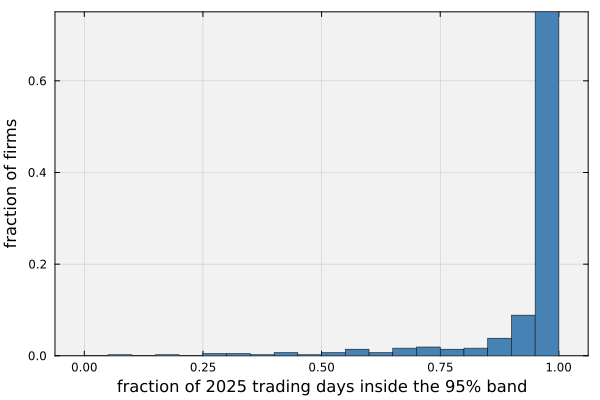

In [16]:
let
    # Include perfect coverage in the last bin; the histogram excludes its rightmost edge -
    bin_edges = collect(0.0:0.05:1.0); # bins are 5 percentage points wide
    bin_edges[end] = nextfloat(1.0); # smallest representable Float64 above one

    # Normalize counts so bar heights sum to one across the scored firms.
    histogram(coverage_df.coverage_95, bins = bin_edges, normalize = :probability, c=:steelblue, lw=0.5, label="",
        xlabel = "fraction of 2025 trading days inside the 95% band", ylabel = "fraction of firms")
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

The distribution shows how coverage varies across assets. A wide prediction band can contain many observations, so high coverage alone does not establish that the model predicts prices precisely.

### Compare assets with high and low coverage
Let's start with the five assets at the top of the sorted table. More than half the assets have 95% coverage of one, so among those the tie-break selects the five whose observed log price stayed closest to the model's median path, i.e., the smallest $z_{\max}$. This ordering refers to coverage of the observed prices, not to investment performance. The table also reports $z_{\max}$, the fitted mean growth rate and volatility, and the final-to-initial VWAP ratio.

The price ratio describes the change between the first and last observations. Coverage and $z_{\max}$ also use the intervening dates: an asset can leave the band early in the year and return before the last observation. Comparing these columns helps us distinguish the overall price change from the deviations along the observed path:

In [17]:
let
    # Compare the highest-coverage firms using diagnostics and fitted parameters -
    cols = [:ticker, :coverage_95, :max_abs_z, :ĝ, :σ̂, :price_ratio];
    highest = first(coverage_df, 5)[:, cols]; # coverage_df is sorted by coverage, then by smallest max_abs_z
    println("Highest coverage (95% band):");
    pretty_table(highest; formatters = [fmt__printf("%.3f", [2,3,4,5,6])])
end

Highest coverage (95% band):
┌────────┬─────────────┬───────────┬─────────┬─────────┬─────────────┐
│ ticker │ coverage_95 │ max_abs_z │       ĝ │       σ̂ │ price_ratio │
│ String │     Float64 │   Float64 │ Float64 │ Float64 │     Float64 │
├────────┼─────────────┼───────────┼─────────┼─────────┼─────────────┤
│    AFL │       1.000 │     0.797 │   0.103 │   0.217 │       1.076 │
│    DRI │       1.000 │     0.831 │   0.111 │   0.315 │       0.989 │
│    XOM │       1.000 │     0.848 │   0.006 │   0.240 │       1.116 │
│     NI │       1.000 │     0.888 │  -0.007 │   0.353 │       1.148 │
│    TJX │       1.000 │     0.919 │   0.119 │   0.236 │       1.271 │
└────────┴─────────────┴───────────┴─────────┴─────────┴─────────────┘


Let's examine the price path for an asset in this high-coverage group. Choose `high_coverage_ticker` in the next cell; `AFL` is one option from the table. Change the ticker and rerun this cell to compare another asset from `list_of_tickers`.

[The `plot_gbm_oos(...)` function](docs/oos-functions.md#plot_gbm_oos) repeats the simulation and plotting calculations from Tasks 1 and 2 using the selected asset's own training estimates and initial 2025 VWAP. The figure shows gray simulated paths, the blue expectation and median, the shaded prediction bands, and the actual price in red. Compare how closely the observed path follows the median with how wide the bands are:


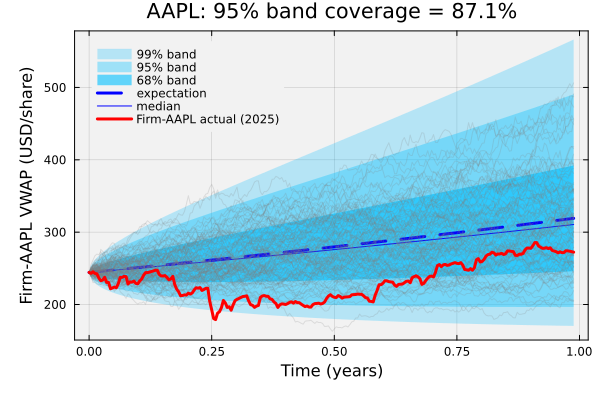

In [18]:
let
    # Choose an asset from the high-coverage table; this selection is independent of Task 1 -
    high_coverage_ticker = "AAPL"; # change this symbol and rerun this cell
    number_of_paths = 100; # number of simulated price trajectories

    # Rebuild the model and initial condition for this asset, then compare with its 2025 prices -
    plot_gbm_oos(high_coverage_ticker, parameters_df, dataset;
        Δt = Δt, number_of_observations = TSIM, number_of_paths = number_of_paths)
end

Compare the price ratios in this first table: high coverage can accompany rising or falling prices because each asset is evaluated against its own fitted prediction band. Look also at the volatility column: a small $z_{\max}$ is only informative when the fitted volatility is itself reasonable, because a wide band makes every deviation look small. Let's now look at the five assets with the lowest coverage. How often did their prices miss the band, and how large were their greatest standardized log-price deviations?

In [18]:
let
    # Use the same columns and precision for the lowest-coverage comparison -
    cols = [:ticker, :coverage_95, :max_abs_z, :ĝ, :σ̂, :price_ratio];
    lowest = last(coverage_df, 5)[:, cols]; # the bottom five rows contain the smallest coverage values
    println("Lowest coverage (95% band):");
    pretty_table(lowest; formatters = [fmt__printf("%.3f", [2,3,4,5,6])])
end

Lowest coverage (95% band):
┌────────┬─────────────┬───────────┬─────────┬─────────┬─────────────┐
│ ticker │ coverage_95 │ max_abs_z │       ĝ │       σ̂ │ price_ratio │
│ String │     Float64 │   Float64 │ Float64 │ Float64 │     Float64 │
├────────┼─────────────┼───────────┼─────────┼─────────┼─────────────┤
│    UNH │       0.305 │     5.349 │   0.190 │   0.224 │       0.655 │
│    GLD │       0.261 │     3.822 │   0.063 │   0.129 │       1.622 │
│    EIX │       0.257 │     9.471 │   0.010 │   0.225 │       0.751 │
│    RHI │       0.177 │     4.211 │   0.061 │   0.272 │       0.395 │
│    CVS │       0.064 │     4.907 │  -0.020 │   0.243 │       1.790 │
└────────┴─────────────┴───────────┴─────────┴─────────┴─────────────┘


Let's now select an asset from the low-coverage group and examine when its observed price departs from the prediction bands. Set `low_coverage_ticker` in the next cell; we start with `CVS`. This selection is independent of the high-coverage example and Task 1. Change the ticker and rerun this cell to inspect another asset from `list_of_tickers`.

We use the same plot format and keep this asset's training estimates fixed throughout 2025. Look for periods when the red observed path stays above or below the bands, and compare those departures with the coverage fraction in the title:


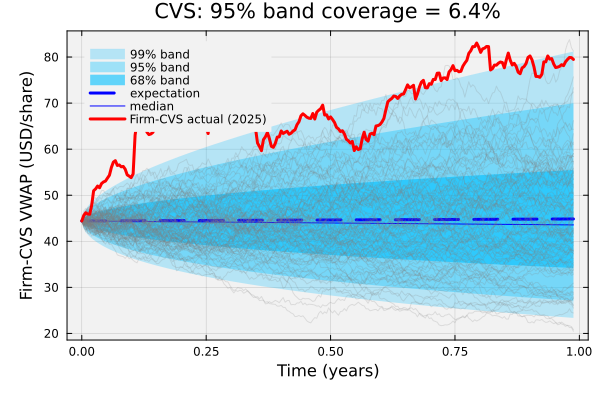

In [20]:
let
    # Choose an asset from the low-coverage table; the high-coverage selection stays unchanged -
    low_coverage_ticker = "CVS"; # change this symbol and rerun this cell
    number_of_paths = 100; # number of simulated price trajectories

    # Use this asset's fitted parameters and first testing price for all simulated paths -
    plot_gbm_oos(low_coverage_ticker, parameters_df, dataset;
        Δt = Δt, number_of_observations = TSIM, number_of_paths = number_of_paths)
end

Read the coverage fraction and the maximum deviation together. Low coverage means the observed price lay outside the band on many forecast days. A large $z_{\max}$ identifies a date when the log price was far from the model's central prediction relative to its modeled standard deviation.

These departures can reflect uncertainty in the fitted parameters, changes in mean growth or volatility after training, or price dynamics such as jumps that the GBM model does not represent. The diagnostics alone do not distinguish these explanations. They identify assets whose fitted models deserve closer examination. The [EMA example](CHEME-5660-L5a-Example-EMA-SAGBM-Fall-2026.ipynb) in this lecture examines whether updating the parameters as new prices arrive improves the forecasts.

___

## Summary
In this example, we applied a single-asset GBM model fitted to 2014 to 2024 data to the 2025 testing period. We compared its price distribution with observed prices, first for one asset and then across the shared dataset.

> __Key Takeaways:__
>
> * **Out-of-sample simulation:** We used mean growth and volatility estimated from earlier data to simulate prices during a later testing period. Converting mean growth to drift supplied the parameters required by the GBM price model.
>
> * **Pointwise prediction bands:** We calculated the model's expected price and lognormal quantile bands with fitted parameters held fixed. The bands describe price uncertainty at individual forecast dates; they do not give the probability that an entire path stays inside them or include uncertainty in the parameter estimates.
>
> * **Coverage diagnostics:** We measured the fraction of forecast dates inside each band and the largest standardized log-price deviation for every asset in the shared dataset. These calculations identified assets for closer examination, while leaving open whether discrepancies arose from fitted parameters or price dynamics absent from the model.

Out-of-sample evaluation connects the model's price predictions with observations made after parameter estimation.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___